# Phase 2 - DETR Parking Space Detection (Augmented Dataset)

This notebook fine-tunes DETR (Detection Transformer) for parking space detection using the **augmented JSON-format dataset**.

**Features:**
- Fine-tunes DETR-ResNet-50 on 2 classes (free, occupied parking spaces)
- Uses augmented dataset at `data/processed/parking_dataset_augmented/`
- JSON format annotations (bbox in pixel coordinates)
- Train/val split from dataset
- Checkpoint saving (best model + periodic checkpoints)
- Early stopping mechanism
- Resume functionality - continue training from checkpoints
- Training and validation loss visualization
- Sample prediction visualization
- Common evaluation metrics for comparison

**Differences from Phase 1:**
- 2 classes instead of 3 (free vs occupied only)
- JSON annotations instead of YOLO TXT format
- Much larger dataset (~36k images)
- Uses `transformers` library DETR (not torchvision)

## 1. Imports & Path Setup

In [ ]:
import os
from pathlib import Path
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.io import read_image
from torchvision.transforms.functional import convert_image_dtype

from transformers import DetrForObjectDetection, DetrConfig, DetrImageProcessor

BASE_DIR = Path.cwd()

# Augmented dataset paths

DATASET_ROOT = BASE_DIR / "parking_dataset_augmented"
IMAGES_DIR = DATASET_ROOT / "images"
ANNOTATIONS_DIR = DATASET_ROOT / "annotations"

# Checkpoint directory
CHECKPOINT_DIR = BASE_DIR / "checkpoints" / "phase2_detr_parking"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


print("BASE_DIR:", BASE_DIR)
print("Dataset root:", DATASET_ROOT)
print("Images directory exists:", IMAGES_DIR.exists())
print("Annotations directory exists:", ANNOTATIONS_DIR.exists())
print("Checkpoint dir:", CHECKPOINT_DIR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/home/alvisngan/Documents/george_brown/deep_learning_2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BASE_DIR: /home/alvisngan/Documents/george_brown/deep_learning_2
Dataset root: /home/alvisngan/Documents/george_brown/deep_learning_2/parking_dataset_augmented
Images directory exists: True
Annotations directory exists: True
Checkpoint dir: /home/alvisngan/Documents/george_brown/deep_learning_2/checkpoints/phase2_detr_parking
Using device: cuda


## 2. Class Names & Label Mapping

**Important**: DETR uses labels {0, 1} for object classes (no background index). DETR adds a "no-object" class internally.

In [ ]:
# Class names (2 classes: free and occupied)
class_names = ["free_parking_space", "not_free_parking_space"]
num_classes = len(class_names)

# DETR: labels should be {0, 1} (no background index, DETR adds no-object internally)
# JSON occupied=False -> 0 (free)
# JSON occupied=True -> 1 (occupied)

print("Classes:", class_names)
print("Number of classes (DETR):", num_classes)

Classes: ['free_parking_space', 'not_free_parking_space']
Number of classes (DETR): 2


## 3. Create Train/Val Split

In [3]:
# Get all annotation files
annotation_files = sorted(list(ANNOTATIONS_DIR.glob("*.json")))
print(f"Total annotation files: {len(annotation_files):,}")

# Split into train/val (80/20 split)
train_files, val_files = train_test_split(
    annotation_files, test_size=0.2, random_state=42
)

print(f"Train files: {len(train_files):,}")
print(f"Val files: {len(val_files):,}")

Total annotation files: 36,426
Train files: 29,140
Val files: 7,286


## 4. Custom Dataset for JSON -> DETR

In [4]:
class JsonDetectionDatasetDetr(Dataset):
    """Dataset that loads JSON annotations and converts to DETR format."""

    def __init__(self, annotation_files, images_dir):
        self.annotation_files = annotation_files
        self.images_dir = images_dir

    def __len__(self):
        return len(self.annotation_files)

    def __getitem__(self, idx):
        ann_path = self.annotation_files[idx]

        # Load annotation JSON
        with open(ann_path, 'r') as f:
            ann = json.load(f)

        # Get image name and load image
        img_name = ann.get('image_name', ann_path.stem + '.jpg')
        img_path = self.images_dir / img_name

        # Read image [C,H,W] in uint8, convert to float [0,1]
        img = read_image(str(img_path))

        # Handle different channel counts
        C, H, W = img.shape
        if C == 1:
            img = img.repeat(3, 1, 1)
        elif C == 4:
            img = img[:3, :, :]
        elif C != 3:
            raise ValueError(f"Unexpected number of channels: {C} for image {img_path}")

        img = convert_image_dtype(img, dtype=torch.float32)
        _, H, W = img.shape

        # Parse bounding boxes from JSON
        boxes = []
        labels = []
        areas = []

        for space in ann.get('spaces', []):
            bbox = space.get('bbox', [])
            occupied = space.get('occupied', False)

            if len(bbox) == 4:
                x_min, y_min, x_max, y_max = map(float, bbox)

                # Clip to image bounds
                x_min = max(0.0, min(float(W), x_min))
                y_min = max(0.0, min(float(H), y_min))
                x_max = max(0.0, min(float(W), x_max))
                y_max = max(0.0, min(float(H), y_max))

                if x_max <= x_min or y_max <= y_min:
                    continue

                # DETR labels: free (occupied=False) -> 0, occupied (occupied=True) -> 1
                cls_detr = 1 if occupied else 0

                # Calculate area
                area = (x_max - x_min) * (y_max - y_min)

                boxes.append([x_min, y_min, x_max, y_max])
                labels.append(cls_detr)
                areas.append(area)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": areas,
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
        }

        return img, target

# Create datasets
train_dataset = JsonDetectionDatasetDetr(train_files, IMAGES_DIR)
val_dataset = JsonDetectionDatasetDetr(val_files, IMAGES_DIR)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

# Note: Test dataset will be created later if needed (3-way split)
# For now, we use train/val split only

Train samples: 29140
Val samples: 7286


In [5]:
# # Limit the dataset size for testing

# # ---- LIMIT SIZES HERE ----
# MAX_TRAIN = 200
# MAX_VAL   = 50

# # Make sure we don't go out of range if dataset is smaller
# train_indices = list(range(min(MAX_TRAIN, len(train_dataset))))
# val_indices   = list(range(min(MAX_VAL,   len(val_dataset))))


# # Subsets that are actually used for training/validation
# train_dataset = Subset(train_dataset, train_indices)
# val_dataset   = Subset(val_dataset,   val_indices)

# print("Train samples (limited):", len(train_dataset))
# print("Val samples (limited):",   len(val_dataset))

Train samples (limited): 200
Val samples (limited): 50


## 5. DataLoader & Collate Function

In [5]:
def detection_collate_fn(batch):
    images = []
    targets = []
    for img, tgt in batch:
        images.append(img)
        targets.append(tgt)
    return images, targets

BATCH_SIZE = 256  # DETR is memory intensive

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=detection_collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=detection_collate_fn,
)

# Note: Test loader will be created later if test dataset is available
# test_loader = DataLoader(
#     test_dataset,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     num_workers=0,
#     collate_fn=detection_collate_fn,
# )


# Quick sanity check
imgs, tgts = next(iter(train_loader))
print("Batch len:", len(imgs), "Image shape:", imgs[0].shape)
print("Targets sample - boxes shape:", tgts[0]["boxes"].shape, "labels:", tgts[0]["labels"])

Batch len: 256 Image shape: torch.Size([3, 640, 640])
Targets sample - boxes shape: torch.Size([90, 4]) labels: tensor([1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
        0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0])


## 6. Load DETR Model & Configure Training

In [6]:
# Load DETR model from transformers
model_name = "facebook/detr-resnet-50"
num_labels = num_classes  # 2 classes

# Load with correct number of labels (this reinitializes classification head)
detr_model = DetrForObjectDetection.from_pretrained(
    model_name,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
).to(device)

detr_model.train()

# Setup optimizer - use best hyperparameters from tuning if available
params = [p for p in detr_model.parameters() if p.requires_grad]

# Try to load best hyperparameters from tuning results
tuning_file = CHECKPOINT_DIR / "hyperparameter_tuning_results.json"
if tuning_file.exists():
    try:
        with open(tuning_file, 'r') as f:
            tuning_results = json.load(f)

        best_params = tuning_results.get('best_params', {})
        learning_rate = best_params.get('learning_rate', 1e-4)
        weight_decay = best_params.get('weight_decay', 1e-4)
        optimizer_name = best_params.get('optimizer', 'AdamW')
        best_batch_size = best_params.get('batch_size', 4)

        print(f"\n✓ Loaded best hyperparameters from tuning results:")
        print(f"  Learning rate: {learning_rate:.6f}")
        print(f"  Weight decay: {weight_decay:.6f}")
        print(f"  Optimizer: {optimizer_name}")
        print(f"  Batch size: {best_batch_size}")
        print(f"  Best validation loss: {tuning_results.get('best_value', 'N/A'):.4f}")

        # Update optimizer with best parameters
        if optimizer_name == "Adam":
            optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=weight_decay)
        else:  # AdamW
            optimizer = torch.optim.AdamW(params, lr=learning_rate, weight_decay=weight_decay)

        # Update batch size and recreate data loaders if they exist
        if BATCH_SIZE != best_batch_size:
            print(f"  → Updating batch size from {BATCH_SIZE} to {best_batch_size}")
            BATCH_SIZE = best_batch_size

            # Recreate data loaders with new batch size if they exist
            if 'train_dataset' in globals() and 'val_dataset' in globals():
                print(f"  → Recreating data loaders with batch size {BATCH_SIZE}")
                train_loader = DataLoader(
                    train_dataset,
                    batch_size=BATCH_SIZE,
                    shuffle=True,
                    num_workers=0,
                    collate_fn=detection_collate_fn,
                )
                val_loader = DataLoader(
                    val_dataset,
                    batch_size=BATCH_SIZE,
                    shuffle=False,
                    num_workers=0,
                    collate_fn=detection_collate_fn,
                )
                print(f"Data loaders recreated")
        else:
            BATCH_SIZE = best_batch_size
            print(f"  → Using optimized hyperparameters for training")

    except Exception as e:
        print(f"\nCould not load hyperparameter tuning results: {e}")
        print("  Using default hyperparameters")
        optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)
else:
    print(f"\nNo hyperparameter tuning results found at {tuning_file}")
    print("  Using default hyperparameters:")
    print("    Learning rate: 1e-4")
    print("    Weight decay: 1e-4")
    print("    Optimizer: AdamW")
    print("Run hyperparameter tuning (Section 9.1) first to optimize these values")
    optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

print("\nDETR Model loaded and configured")
print(f"Total parameters: {sum(p.numel() for p in detr_model.parameters() if p.requires_grad):,}")

/home/alvisngan/Documents/george_brown/deep_learning_2/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:2409: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/alvisngan/Documents/george_brown/deep_learning_2/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:2409: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/alvisngan/Documents/george_brown/deep_learning_2/.venv/lib/python3.13/site-packages/torch/nn/modules/module.py:2409: UserWarni


✓ Loaded best hyperparameters from tuning results:
  Learning rate: 0.000015
  Weight decay: 0.000140
  Optimizer: AdamW
  Batch size: 2
  Best validation loss: 2.2789
  → Updating batch size from 256 to 2
  → Recreating data loaders with batch size 2
Data loaders recreated

DETR Model loaded and configured
Total parameters: 41,279,495


In [7]:
# Load DETR model from transformers
model_name = "facebook/detr-resnet-50"
num_labels = num_classes  # 2 classes

# Load with correct number of labels
detr_model = DetrForObjectDetection.from_pretrained(
    model_name,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
).to(device)

detr_model.train()

# Setup optimizer - use best hyperparameters from tuning if available
params = [p for p in detr_model.parameters() if p.requires_grad]

# Try to load best hyperparameters from tuning results
tuning_file = CHECKPOINT_DIR / "hyperparameter_tuning_results.json"
if tuning_file.exists():
    try:
        with open(tuning_file, 'r') as f:
            tuning_results = json.load(f)

        best_params = tuning_results.get('best_params', {})
        learning_rate = best_params.get('learning_rate', 1e-4)
        weight_decay = best_params.get('weight_decay', 1e-4)
        optimizer_name = best_params.get('optimizer', 'AdamW')
        best_batch_size = best_params.get('batch_size', 4)

        print(f"\n✓ Loaded best hyperparameters from tuning results:")
        print(f"  Learning rate: {learning_rate:.6f}")
        print(f"  Weight decay: {weight_decay:.6f}")
        print(f"  Optimizer: {optimizer_name}")
        print(f"  Batch size: {best_batch_size}")
        print(f"  Best validation loss: {tuning_results.get('best_value', 'N/A'):.4f}")

        # Update optimizer with best parameters
        if optimizer_name == "Adam":
            optimizer = torch.optim.Adam(params, lr=learning_rate, weight_decay=weight_decay)
        else:  # AdamW
            optimizer = torch.optim.AdamW(params, lr=learning_rate, weight_decay=weight_decay)

        # Update batch size and recreate data loaders if they exist
        if BATCH_SIZE != best_batch_size:
            print(f"  → Updating batch size from {BATCH_SIZE} to {best_batch_size}")
            BATCH_SIZE = best_batch_size

            # Recreate data loaders with new batch size if they exist
            if 'train_dataset' in globals() and 'val_dataset' in globals():
                print(f"  → Recreating data loaders with batch size {BATCH_SIZE}")
                train_loader = DataLoader(
                    train_dataset,
                    batch_size=BATCH_SIZE,
                    shuffle=True,
                    num_workers=0,
                    collate_fn=detection_collate_fn,
                )
                val_loader = DataLoader(
                    val_dataset,
                    batch_size=BATCH_SIZE,
                    shuffle=False,
                    num_workers=0,
                    collate_fn=detection_collate_fn,
                )
                print(f"Data loaders recreated")
        else:
            BATCH_SIZE = best_batch_size
            print(f"  → Using optimized hyperparameters for training")

    except Exception as e:
        print(f"\nCould not load hyperparameter tuning results: {e}")
        print("  Using default hyperparameters")
        optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)
else:
    print(f"\nNo hyperparameter tuning results found at {tuning_file}")
    print("  Using default hyperparameters")
    print("Run hyperparameter tuning (Section 9.1) first to optimize these values")
    optimizer = torch.optim.AdamW(params, lr=1e-4, weight_decay=1e-4)

print("\nDETR Model loaded and configured")
print(f"Total parameters: {sum(p.numel() for p in detr_model.parameters() if p.requires_grad):,}")

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin


✓ Loaded best hyperparameters from tuning results:
  Learning rate: 0.000015
  Weight decay: 0.000140
  Optimizer: AdamW
  Batch size: 2
  Best validation loss: 2.2789
  → Using optimized hyperparameters for training

DETR Model loaded and configured
Total parameters: 41,279,495


### 7.1. Model Architecture Description

### DETR-ResNet-50 Architecture Overview

**Model Type:** Transformer-based detector

**Key Components:**
- Backbone: ResNet-50 backbone with Transformer encoder-decoder
- Detection Head: Transformer decoder with object queries (no anchors/NMS)
- Loss Function: Set prediction loss (bipartite matching + classification/bbox loss)

**Why This Architecture?**
DETR uses modern transformer architecture, eliminating the need for anchor boxes and NMS, providing end-to-end training.

**Model Statistics:**
- Total Parameters: [Will be calculated after model loading]
- Trainable Parameters: [Will be calculated]
- Model Size: [Will be calculated] MB

In [9]:
# Calculate model statistics
total_params = sum(p.numel() for p in detr_model.parameters())
trainable_params = sum(p.numel() for p in detr_model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Non-trainable Parameters: {total_params - trainable_params:,}")

# Estimate model size (in MB)
model_size_mb = total_params * 4 / (1024 * 1024)  # Assuming float32 (4 bytes)
print(f"Estimated Model Size: {model_size_mb:.2f} MB")

Total Parameters: 41,501,895
Trainable Parameters: 41,279,495
Non-trainable Parameters: 222,400
Estimated Model Size: 158.32 MB


## 8. Training Configuration

In [10]:
NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 7
MIN_DELTA = 0.001
CHECKPOINT_EVERY = 1

print("Training Configuration:")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Early Stopping Patience: {EARLY_STOPPING_PATIENCE} epochs")
print(f"  Min Delta: {MIN_DELTA}")
print(f"  Checkpoint Every: {CHECKPOINT_EVERY} epochs")

Training Configuration:
  Epochs: 10
  Early Stopping Patience: 7 epochs
  Min Delta: 0.001
  Checkpoint Every: 1 epochs


### 9.1. Hyperparameter Tuning

This section explores different hyperparameter configurations to optimize DETR-ResNet-50 performance.

**Hyperparameters to Test:**
- Learning Rate: 1e-4, 5e-4, 1e-3
- Batch Size: 4, 8, 16
- Optimizer: Adam, AdamW, SGD
- Additional model-specific hyperparameters

**Note:** Run experiments with different hyperparameters and document results below.

In [ ]:

import optuna
from optuna.pruners import MedianPruner
import pandas as pd

def create_objective_detr(trial):
    """
    Optuna objective function for DETR hyperparameter tuning.
    Returns validation loss to minimize.
    """
    # Suggest hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [2, 4, 8])
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW"])
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

        # Create model copy for this trial
    config = DetrConfig.from_pretrained(model_name)
    config.num_labels = num_labels
    model_trial = DetrForObjectDetection.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    ).to(device)

    # Initialize processor for this trial
    processor_trial = DetrImageProcessor.from_pretrained(model_name)

    # Helper function to recursively move tensors to device (in-place modification)
    def move_to_device_inplace(obj, device):
        """Recursively move tensors in nested structures to device (modifies in place)"""
        if isinstance(obj, torch.Tensor):
            if obj.device != device:
                return obj.to(device)
            return obj
        elif isinstance(obj, dict):
            for k, v in obj.items():
                obj[k] = move_to_device_inplace(v, device)
            return obj
        elif isinstance(obj, list):
            for i, item in enumerate(obj):
                obj[i] = move_to_device_inplace(item, device)
            return obj
        elif isinstance(obj, tuple):
            # Tuples are immutable, so we need to create a new one
            return tuple(move_to_device_inplace(item, device) for item in obj)
        elif hasattr(obj, 'to'):  # Handle objects with .to() method (like BatchEncoding)
            try:
                return obj.to(device)
            except:
                # If .to() doesn't work, try to convert dict representation
                if hasattr(obj, '__dict__'):
                    move_to_device_inplace(obj.__dict__, device)
                return obj
        else:
            return obj

    # Also keep the original function for cases where we need a new object
    def move_to_device(obj, device):
        """Recursively move tensors in nested structures to device"""
        return move_to_device_inplace(obj, device)

    # Setup optimizer
    params = [p for p in model_trial.parameters() if p.requires_grad]
    if optimizer_name == "Adam":
        optimizer_trial = torch.optim.Adam(params, lr=learning_rate, weight_decay=weight_decay)
    else:  # AdamW
        optimizer_trial = torch.optim.AdamW(params, lr=learning_rate, weight_decay=weight_decay)

    # Create data loaders with trial batch size
    train_loader_trial = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        collate_fn=detection_collate_fn,
    )
    val_loader_trial = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        collate_fn=detection_collate_fn,
    )

    # Short training loop for hyperparameter search
    NUM_TRIAL_EPOCHS = 5
    best_val_loss = float('inf')

    # Print trial info
    print(f"\n[Trial {trial.number}] Starting trial with params: {trial.params}")
    print(f"  Learning rate: {learning_rate:.6f}, Batch size: {batch_size}, Optimizer: {optimizer_name}, Weight decay: {weight_decay:.6f}")

    for epoch in range(1, NUM_TRIAL_EPOCHS + 1):
        # Train
        model_trial.train()
        train_loss = 0.0
        num_batches = 0
        total_batches = len(train_loader_trial)
        for batch_idx, (images, targets) in enumerate(train_loader_trial):
            # Convert targets to COCO format expected by DETR processor
            batch_targets = []
            for idx, tgt in enumerate(targets):
                # Convert boxes from [x_min, y_min, x_max, y_max] to COCO format [x_min, y_min, width, height]
                boxes = tgt["boxes"].clone()
                labels = tgt["labels"]

                # Create COCO format annotations
                coco_annotations = []
                if len(boxes) > 0:
                    # Convert to width/height format
                    boxes[:, 2] = boxes[:, 2] - boxes[:, 0]  # width
                    boxes[:, 3] = boxes[:, 3] - boxes[:, 1]  # height

                    areas = tgt.get("area", torch.zeros(len(boxes), dtype=torch.float32))
                    iscrowds = tgt.get("iscrowd", torch.zeros(len(boxes), dtype=torch.int64))

                    for i in range(len(boxes)):
                        coco_annotations.append({
                            "bbox": boxes[i].tolist(),
                            "category_id": int(labels[i].item()),
                            "area": float(areas[i].item()),
                            "iscrowd": int(iscrowds[i].item()),
                        })

                batch_targets.append({
                    "image_id": int(tgt.get("image_id", torch.tensor([idx]))[0].item()),
                    "annotations": coco_annotations
                })

            inputs = processor_trial(images=[img.cpu() for img in images], annotations=batch_targets, return_tensors="pt")
            # Handle BatchEncoding objects (processor may return this)
            if hasattr(inputs, 'to'):
                try:
                    inputs = inputs.to(device)
                except:
                    pass
            # Convert to dict if needed and move all tensors to device
            if not isinstance(inputs, dict):
                inputs = dict(inputs) if hasattr(inputs, '__iter__') else inputs
            # Move all tensors to device (in-place modification ensures nested structures are handled)
            move_to_device_inplace(inputs, device)
            # Force move any remaining tensors - processor may create labels in special format
            for key in list(inputs.keys()):
                val = inputs[key]
                if isinstance(val, torch.Tensor):
                    inputs[key] = val.to(device)
                # Handle special case: labels might be a list of dicts with tensors
                elif isinstance(val, list) and len(val) > 0 and isinstance(val[0], dict):
                    for item in val:
                        if isinstance(item, dict):
                            for k, v in item.items():
                                if isinstance(v, torch.Tensor):
                                    item[k] = v.to(device)
            outputs = model_trial(**inputs)
            loss = outputs.loss

            optimizer_trial.zero_grad()
            loss.backward()
            optimizer_trial.step()

            train_loss += loss.item()
            num_batches += 1
            # Print progress every 10 batches
            if (batch_idx + 1) % 10 == 0 or (batch_idx + 1) == total_batches:
                print(f"  [Trial {trial.number}] Epoch {epoch}/{NUM_TRIAL_EPOCHS}, Batch {batch_idx + 1}/{total_batches}, Loss: {loss.item():.4f}")
        train_loss = train_loss / max(1, num_batches)
        print(f"  [Trial {trial.number}] Epoch {epoch} - Train Loss: {train_loss:.4f}")

        # Validate
        model_trial.eval()
        val_loss = 0.0
        num_batches = 0
        with torch.no_grad():
            for images, targets in val_loader_trial:
                # Convert targets to COCO format expected by DETR processor
                batch_targets = []
                for idx, tgt in enumerate(targets):
                    # Convert boxes from [x_min, y_min, x_max, y_max] to COCO format [x_min, y_min, width, height]
                    boxes = tgt["boxes"].clone()
                    if len(boxes) > 0:
                        boxes[:, 2] = boxes[:, 2] - boxes[:, 0]  # width
                        boxes[:, 3] = boxes[:, 3] - boxes[:, 1]  # height

                    # Create COCO format annotations
                    coco_annotations = []
                    for i in range(len(boxes)):
                        coco_annotations.append({
                            "bbox": boxes[i].tolist(),
                            "category_id": int(tgt["labels"][i].item()),
                            "area": float(tgt.get("area", torch.zeros(len(tgt["boxes"]), dtype=torch.float32))[i].item()),
                            "iscrowd": int(tgt.get("iscrowd", torch.zeros(len(tgt["boxes"]), dtype=torch.int64))[i].item()),
                        })

                    batch_targets.append({
                        "image_id": int(tgt.get("image_id", torch.tensor([idx]))[0].item()),
                        "annotations": coco_annotations
                    })

                inputs = processor_trial(images=[img.cpu() for img in images], annotations=batch_targets, return_tensors="pt")
                # Handle BatchEncoding objects (processor may return this)
                if hasattr(inputs, 'to'):
                    try:
                        inputs = inputs.to(device)
                    except:
                        pass
                # Convert to dict if needed and move all tensors to device
                if not isinstance(inputs, dict):
                    inputs = dict(inputs) if hasattr(inputs, '__iter__') else inputs
                # Move all tensors to device (in-place modification ensures nested structures are handled)
                move_to_device_inplace(inputs, device)
                # Force move any remaining tensors - processor may create labels in special format
                for key in list(inputs.keys()):
                    val = inputs[key]
                    if isinstance(val, torch.Tensor):
                        inputs[key] = val.to(device)
                    # Handle special case: labels might be a list of dicts with tensors
                    elif isinstance(val, list) and len(val) > 0 and isinstance(val[0], dict):
                        for item in val:
                            if isinstance(item, dict):
                                for k, v in item.items():
                                    if isinstance(v, torch.Tensor):
                                        item[k] = v.to(device)
                outputs = model_trial(**inputs)
                loss = outputs.loss
                val_loss += loss.item()
                num_batches += 1
        val_loss = val_loss / max(1, num_batches)
        print(f"  [Trial {trial.number}] Epoch {epoch} - Val Loss: {val_loss:.4f}")

        # Report to Optuna (for pruning)
        trial.report(val_loss, epoch)

        # Handle pruning
        if trial.should_prune():
            print(f"  [Trial {trial.number}] Pruned at epoch {epoch}")
            raise optuna.TrialPruned()

        if val_loss < best_val_loss:
            best_val_loss = val_loss

    print(f"[Trial {trial.number}] Completed! Best val loss: {best_val_loss:.4f}\n")
    return best_val_loss

# Run hyperparameter tuning
print("=" * 60)
print("Hyperparameter Tuning Setup")
print("=" * 60)

# Create subfolder for Optuna study storage
OPTUNA_STUDY_DIR = CHECKPOINT_DIR / "optuna_study"
OPTUNA_STUDY_DIR.mkdir(parents=True, exist_ok=True)

# SQLite database path for persistent storage
STUDY_DB_PATH = OPTUNA_STUDY_DIR / "optuna_study.db"
STUDY_NAME = "detr_hyperparameter_tuning"

# Check if study database exists (resume) or create new
storage_url = f"sqlite:///{STUDY_DB_PATH}"

try:
    # Try to load existing study
    study = optuna.load_study(
        study_name=STUDY_NAME,
        storage=storage_url,
        pruner=MedianPruner(n_startup_trials=1, n_warmup_steps=2)
    )
    completed_trials = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    print(f"✓ Resuming existing study from: {STUDY_DB_PATH}")
    print(f"  Completed trials: {completed_trials}")
    print(f"  Total trials: {len(study.trials)}")
    # Only access best_value if there are completed trials
    if completed_trials > 0:
        try:
            best_so_far = study.best_value
            print(f"  Best value so far: {best_so_far:.4f}")
        except:
            print(f"  No best value available yet")
    else:
        print(f"  No completed trials yet - study is ready to continue")
except optuna.exceptions.DuplicatedStudyError:
    # Study exists but couldn't load it - try to load with load_if_exists
    print(f"✓ Study exists, loading it...")
    study = optuna.load_study(
        study_name=STUDY_NAME,
        storage=storage_url,
        pruner=MedianPruner(n_startup_trials=1, n_warmup_steps=2)
    )
    completed_trials = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    print(f"  Completed trials: {completed_trials}")
    print(f"  Total trials: {len(study.trials)}")
except:
    # Create new study if it doesn't exist
    print(f"✓ Creating new study at: {STUDY_DB_PATH}")
    study = optuna.create_study(
        direction="minimize",
        pruner=MedianPruner(n_startup_trials=1, n_warmup_steps=2),
        study_name=STUDY_NAME,
        storage=storage_url,
        load_if_exists=True
    )

# Run optimization (fewer trials for DETR due to slower training)
N_TRIALS = 10
completed_trials = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
remaining_trials = max(0, N_TRIALS - completed_trials)

print(f"\nStarting hyperparameter optimization...")
print(f"  Target trials: {N_TRIALS}")
print(f"  Completed: {completed_trials}")
print(f"  Remaining: {remaining_trials}")
print(f"  Study database: {STUDY_DB_PATH}")
print(f"This may take a while - each trial trains for 5 epochs.")
print(f"Progress will be shown below:\n")

if remaining_trials > 0:
    study.optimize(create_objective_detr, n_trials=remaining_trials, timeout=None, show_progress_bar=True)
else:
    print("All trials already completed!")

print("\n" + "=" * 60)
print("Hyperparameter Tuning Results:")
print("=" * 60)
print(f"Number of trials: {len(study.trials)}")
print(f"Best trial:")
trial = study.best_trial
print(f"  Value (val_loss): {trial.value:.4f}")
print(f"  Params:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# Save results
tuning_results = {
    'best_params': trial.params,
    'best_value': float(trial.value),
    'n_trials': len(study.trials)
}

tuning_file = CHECKPOINT_DIR / "hyperparameter_tuning_results.json"
with open(tuning_file, 'w') as f:
    json.dump(tuning_results, f, indent=2)
print(f"\nTuning results saved to: {tuning_file}")
print(f"Study database saved to: {STUDY_DB_PATH}")
print(f"You can resume tuning by running this cell again!")

# Create comparison DataFrame
trial_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trial_data.append({
            **t.params,
            'val_loss': t.value,
            'state': t.state.name
        })

if trial_data:
    tuning_df = pd.DataFrame(trial_data)
    tuning_df = tuning_df.sort_values('val_loss', ascending=True)
    print("\nTop 5 Trials:")
    print(tuning_df.head(5).to_string(index=False))

print("  Learning Rate: 1e-5, 5e-5, 1e-4")
print("  Batch Size: 2, 4, 8")
print("  Optimizer: Adam, AdamW")
print("  Weight Decay: 1e-5 to 1e-3 (log scale)")


Hyperparameter Tuning Setup


[I 2025-12-05 09:41:09,127] A new study created in RDB with name: detr_hyperparameter_tuning


✓ Creating new study at: /home/alvisngan/Documents/george_brown/deep_learning_2/checkpoints/phase2_faster_rcnn_parking/optuna_study/optuna_study.db

Starting hyperparameter optimization...
  Target trials: 10
  Completed: 0
  Remaining: 10
  Study database: /home/alvisngan/Documents/george_brown/deep_learning_2/checkpoints/phase2_faster_rcnn_parking/optuna_study/optuna_study.db
This may take a while - each trial trains for 5 epochs.
Progress will be shown below:



  0%|          | 0/10 [00:00<?, ?it/s]Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were no


[Trial 0] Starting trial with params: {'learning_rate': 4.1850937988523456e-05, 'batch_size': 2, 'optimizer': 'Adam', 'weight_decay': 0.0003503230706350762}
  Learning rate: 0.000042, Batch size: 2, Optimizer: Adam, Weight decay: 0.000350
  [Trial 0] Epoch 1/5, Batch 10/100, Loss: 4.0045
  [Trial 0] Epoch 1/5, Batch 20/100, Loss: 3.7827
  [Trial 0] Epoch 1/5, Batch 30/100, Loss: 3.6522
  [Trial 0] Epoch 1/5, Batch 40/100, Loss: 3.8412
  [Trial 0] Epoch 1/5, Batch 50/100, Loss: 3.3174
  [Trial 0] Epoch 1/5, Batch 60/100, Loss: 3.4989
  [Trial 0] Epoch 1/5, Batch 70/100, Loss: 3.1661
  [Trial 0] Epoch 1/5, Batch 80/100, Loss: 3.3297
  [Trial 0] Epoch 1/5, Batch 90/100, Loss: 3.2333
  [Trial 0] Epoch 1/5, Batch 100/100, Loss: 3.5442
  [Trial 0] Epoch 1 - Train Loss: 3.6574
  [Trial 0] Epoch 1 - Val Loss: 3.1437
  [Trial 0] Epoch 2/5, Batch 10/100, Loss: 3.2807
  [Trial 0] Epoch 2/5, Batch 20/100, Loss: 3.0253
  [Trial 0] Epoch 2/5, Batch 30/100, Loss: 3.2172
  [Trial 0] Epoch 2/5, Batch 

...

  [Trial 8] Epoch 5 - Val Loss: 2.2789
[Trial 8] Completed! Best val loss: 2.2789

[I 2025-12-05 09:58:55,934] Trial 8 finished with value: 2.2789350509643556 and parameters: {'learning_rate': 1.548745525488646e-05, 'batch_size': 2, 'optimizer': 'AdamW', 'weight_decay': 0.0001404465096409123}. Best is trial 8 with value: 2.2789350509643556.


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin


[Trial 9] Starting trial with params: {'learning_rate': 0.0004313010393213216, 'batch_size': 4, 'optimizer': 'Adam', 'weight_decay': 0.0005201668494553413}
  Learning rate: 0.000431, Batch size: 4, Optimizer: Adam, Weight decay: 0.000520
  [Trial 9] Epoch 1/5, Batch 10/50, Loss: 3.2544
  [Trial 9] Epoch 1/5, Batch 20/50, Loss: 2.8489
  [Trial 9] Epoch 1/5, Batch 30/50, Loss: 2.8639
  [Trial 9] Epoch 1/5, Batch 40/50, Loss: 3.1356
  [Trial 9] Epoch 1/5, Batch 50/50, Loss: 3.1654
  [Trial 9] Epoch 1 - Train Loss: 3.2312
  [Trial 9] Epoch 1 - Val Loss: 2.9014
  [Trial 9] Epoch 2/5, Batch 10/50, Loss: 2.8909
  [Trial 9] Epoch 2/5, Batch 20/50, Loss: 2.6942
  [Trial 9] Epoch 2/5, Batch 30/50, Loss: 2.2287
  [Trial 9] Epoch 2/5, Batch 40/50, Loss: 2.3120
  [Trial 9] Epoch 2/5, Batch 50/50, Loss: 3.1237
  [Trial 9] Epoch 2 - Train Loss: 2.6944


Best trial: 8. Best value: 2.27894: 100%|██████████| 10/10 [19:08<00:00, 114.90s/it]

  [Trial 9] Epoch 2 - Val Loss: 2.9942
  [Trial 9] Pruned at epoch 2
[I 2025-12-05 10:00:18,138] Trial 9 pruned. 

Hyperparameter Tuning Results:
Number of trials: 10
Best trial:
  Value (val_loss): 2.2789
  Params:
    learning_rate: 1.548745525488646e-05
    batch_size: 2
    optimizer: AdamW
    weight_decay: 0.0001404465096409123

Tuning results saved to: /home/alvisngan/Documents/george_brown/deep_learning_2/checkpoints/phase2_faster_rcnn_parking/hyperparameter_tuning_results.json
Study database saved to: /home/alvisngan/Documents/george_brown/deep_learning_2/checkpoints/phase2_faster_rcnn_parking/optuna_study/optuna_study.db
You can resume tuning by running this cell again!

Top 5 Trials:
 learning_rate  batch_size optimizer  weight_decay  val_loss    state
      0.000015           2     AdamW       0.00014  2.278935 COMPLETE
      0.000042           2      Adam       0.00035  2.696773 COMPLETE
  Learning Rate: 1e-5, 5e-5, 1e-4
  Batch Size: 2, 4, 8
  Optimizer: Adam, AdamW
  Wei

## 10. Training Functions

In [ ]:
# Initialize image processor for DETR
processor = DetrImageProcessor.from_pretrained(model_name)

# Helper function to recursively move tensors to device (same as in hyperparameter tuning)
def move_to_device_inplace(obj, device):
    """Recursively move tensors in nested structures to device (modifies in place)"""
    if isinstance(obj, torch.Tensor):
        if obj.device != device:
            return obj.to(device)
        return obj
    elif isinstance(obj, dict):
        for k, v in obj.items():
            obj[k] = move_to_device_inplace(v, device)
        return obj
    elif isinstance(obj, list):
        for i, item in enumerate(obj):
            obj[i] = move_to_device_inplace(item, device)
        return obj
    elif isinstance(obj, tuple):
        # Tuples are immutable, so we need to create a new one
        return tuple(move_to_device_inplace(item, device) for item in obj)
    elif hasattr(obj, 'to'):  # Handle objects with .to() method (like BatchEncoding)
        try:
            return obj.to(device)
        except:
            # If .to() doesn't work, try to convert dict representation
            if hasattr(obj, '__dict__'):
                move_to_device_inplace(obj.__dict__, device)
            return obj
    else:
        return obj

def train_one_epoch_detr(model, data_loader, optimizer, device, processor):
    model.train()
    running_loss = 0.0
    num_batches = 0
    total_batches = len(data_loader)

    # NEW: wrap data_loader with tqdm
    progress_bar = tqdm(
        enumerate(data_loader),
        total=total_batches,
        desc="Train",
        unit="batch",
        leave=False,
    )

    for batch_idx, (images, targets) in progress_bar:
        # Convert targets to COCO format expected by DETR processor
        batch_targets = []
        for idx, tgt in enumerate(targets):
            # Convert boxes from [x_min, y_min, x_max, y_max] to COCO format [x_min, y_min, width, height]
            boxes = tgt["boxes"].clone()
            labels = tgt["labels"]

            # Create COCO format annotations
            coco_annotations = []
            if len(boxes) > 0:
                # Convert to width/height format
                boxes[:, 2] = boxes[:, 2] - boxes[:, 0]  # width
                boxes[:, 3] = boxes[:, 3] - boxes[:, 1]  # height

                areas = tgt.get("area", torch.zeros(len(boxes), dtype=torch.float32))
                iscrowds = tgt.get("iscrowd", torch.zeros(len(boxes), dtype=torch.int64))

                for i in range(len(boxes)):
                    coco_annotations.append({
                        "bbox": boxes[i].tolist(),
                        "category_id": int(labels[i].item()),
                        "area": float(areas[i].item()),
                        "iscrowd": int(iscrowds[i].item()),
                    })

            batch_targets.append({
                "image_id": int(tgt.get("image_id", torch.tensor([idx]))[0].item()),
                "annotations": coco_annotations
            })

        # Prepare inputs
        inputs = processor(
            images=[img.cpu() for img in images],
            annotations=batch_targets,
            return_tensors="pt",
        )

        # Handle BatchEncoding objects (processor may return this)
        if hasattr(inputs, 'to'):
            try:
                inputs = inputs.to(device)
            except:
                pass

        # Convert to dict if needed and move all tensors to device
        if not isinstance(inputs, dict):
            inputs = dict(inputs) if hasattr(inputs, '__iter__') else inputs

        # Move all tensors to device (in-place modification ensures nested structures are handled)
        move_to_device_inplace(inputs, device)

        # Force move any remaining tensors - processor may create labels in special format
        for key in list(inputs.keys()):
            val = inputs[key]
            if isinstance(val, torch.Tensor):
                inputs[key] = val.to(device)
            # Handle special case: labels might be a list of dicts with tensors
            elif isinstance(val, list) and len(val) > 0 and isinstance(val[0], dict):
                for item in val:
                    if isinstance(item, dict):
                        for k, v in item.items():
                            if isinstance(v, torch.Tensor):
                                item[k] = v.to(device)

        # Forward pass
        outputs = model(**inputs)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1

        # NEW: update tqdm postfix instead of printing every 100 batches
        avg_loss = running_loss / num_batches
        progress_bar.set_postfix(loss=loss.item(), avg_loss=avg_loss)

    return running_loss / max(1, num_batches)

@torch.no_grad()
def evaluate_detr(model, data_loader, device, processor):
    model.eval()
    running_loss = 0.0
    num_batches = 0
    total_batches = len(data_loader)

    # NEW: wrap data_loader with tqdm
    progress_bar = tqdm(
        enumerate(data_loader),
        total=total_batches,
        desc="Val",
        unit="batch",
        leave=False,
    )

    for batch_idx, (images, targets) in progress_bar:
        # Convert targets to COCO format expected by DETR processor
        batch_targets = []
        for idx, tgt in enumerate(targets):
            # Convert boxes from [x_min, y_min, x_max, y_max] to COCO format [x_min, y_min, width, height]
            boxes = tgt["boxes"].clone()
            labels = tgt["labels"]

            # Create COCO format annotations
            coco_annotations = []
            if len(boxes) > 0:
                # Convert to width/height format
                boxes[:, 2] = boxes[:, 2] - boxes[:, 0]  # width
                boxes[:, 3] = boxes[:, 3] - boxes[:, 1]  # height

                areas = tgt.get("area", torch.zeros(len(boxes), dtype=torch.float32))
                iscrowds = tgt.get("iscrowd", torch.zeros(len(boxes), dtype=torch.int64))

                for i in range(len(boxes)):
                    coco_annotations.append({
                        "bbox": boxes[i].tolist(),
                        "category_id": int(labels[i].item()),
                        "area": float(areas[i].item()),
                        "iscrowd": int(iscrowds[i].item()),
                    })

            batch_targets.append({
                "image_id": int(tgt.get("image_id", torch.tensor([idx]))[0].item()),
                "annotations": coco_annotations
            })

        inputs = processor(
            images=[img.cpu() for img in images],
            annotations=batch_targets,
            return_tensors="pt",
        )

        # Handle BatchEncoding objects (processor may return this)
        if hasattr(inputs, 'to'):
            try:
                inputs = inputs.to(device)
            except:
                pass

        # Convert to dict if needed and move all tensors to device
        if not isinstance(inputs, dict):
            inputs = dict(inputs) if hasattr(inputs, '__iter__') else inputs

        # Move all tensors to device (in-place modification ensures nested structures are handled)
        move_to_device_inplace(inputs, device)

        # Force move any remaining tensors - processor may create labels in special format
        for key in list(inputs.keys()):
            val = inputs[key]
            if isinstance(val, torch.Tensor):
                inputs[key] = val.to(device)
            # Handle special case: labels might be a list of dicts with tensors
            elif isinstance(val, list) and len(val) > 0 and isinstance(val[0], dict):
                for item in val:
                    if isinstance(item, dict):
                        for k, v in item.items():
                            if isinstance(v, torch.Tensor):
                                item[k] = v.to(device)

        outputs = model(**inputs)
        loss = outputs.loss
        running_loss += loss.item()
        num_batches += 1

        # NEW: update tqdm postfix instead of printing every 50 batches
        avg_loss = running_loss / num_batches
        progress_bar.set_postfix(loss=loss.item(), avg_loss=avg_loss)

    return running_loss / max(1, num_batches)

print("Training functions defined")

Training functions defined


## 11. Training Loop with Early Stopping, Checkpoints, and Resume

In [12]:
# Initialize training state
start_epoch = 1
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}
patience_counter = 0
best_epoch = 0

# Try to load checkpoint
best_model_path = CHECKPOINT_DIR / "best_model.pt"
if best_model_path.exists():
    print(f"Found existing checkpoint: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)

    detr_model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    best_epoch = checkpoint.get('best_epoch', checkpoint['epoch'])
    history = checkpoint.get('history', history)
    patience_counter = checkpoint.get('patience_counter', 0)

    print(f"Resuming training from epoch {start_epoch}")
    print(f"Previous best: Val Loss = {best_val_loss:.4f} at epoch {best_epoch}")
else:
    print("No existing checkpoint found. Starting fresh training.")

start_time = time.time()

print(f"\n{'='*60}")
print(f"Starting Training")
print(f"{'='*60}")
print(f"Total epochs: {NUM_EPOCHS}")
print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches per epoch: {len(val_loader)}")
print(f"Device: {device}")
print(f"{'='*60}\n")

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    epoch_start_time = time.time()
    print(f"\n{'='*60}")
    print(f"Epoch [{epoch}/{NUM_EPOCHS}] - Training...")
    print(f"{'='*60}")
    train_loss = train_one_epoch_detr(detr_model, train_loader, optimizer, device, processor)
    print(f"\nEpoch [{epoch}/{NUM_EPOCHS}] - Validating...")
    val_loss = evaluate_detr(detr_model, val_loader, device, processor)
    epoch_time = time.time() - epoch_start_time
    print(f"\nEpoch [{epoch}/{NUM_EPOCHS}] completed in {epoch_time/60:.2f} minutes")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    improved = False
    if val_loss < best_val_loss - MIN_DELTA:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        improved = True

        torch.save({
            'epoch': epoch,
            'model_state_dict': detr_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
            'best_epoch': best_epoch,
            'patience_counter': patience_counter,
            'history': history,
        }, best_model_path)
        print(f"  -> New best model saved! (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1

    if epoch % CHECKPOINT_EVERY == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch}.pt"
        torch.save({
            'epoch': epoch,
            'model_state_dict': detr_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'history': history,
            'best_epoch': best_epoch,
        }, checkpoint_path)
        print(f"  -> Checkpoint saved: {checkpoint_path.name}")

    print(f"Epoch [{epoch}/{NUM_EPOCHS}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}{' *' if improved else ''}")

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping triggered! No improvement for {EARLY_STOPPING_PATIENCE} epochs.")
        print(f"Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")
        break

end_time = time.time()
print(f"\nTraining finished in {(end_time - start_time)/60:.2f} minutes.")
print(f"Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")

No existing checkpoint found. Starting fresh training.

Starting Training
Total epochs: 10
Train batches per epoch: 14570
Val batches per epoch: 3643
Device: cuda


Epoch [1/10] - Training...


Train:   0%|          | 0/14570 [00:00<?, ?batch/s]It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.



Epoch [1/10] - Validating...



Epoch [1/10] completed in 109.63 minutes
  -> New best model saved! (Val Loss: 0.3745)
  -> Checkpoint saved: checkpoint_epoch_1.pt
Epoch [1/10] Train Loss: 1.2173 | Val Loss: 0.3745 *

Epoch [2/10] - Training...



Epoch [2/10] - Validating...


...


Epoch [8/10] completed in 108.24 minutes
  -> Checkpoint saved: checkpoint_epoch_8.pt
Epoch [8/10] Train Loss: 0.1244 | Val Loss: 0.1269

Epoch [9/10] - Training...



Epoch [9/10] - Validating...



Epoch [9/10] completed in 108.28 minutes
  -> New best model saved! (Val Loss: 0.1011)
  -> Checkpoint saved: checkpoint_epoch_9.pt
Epoch [9/10] Train Loss: 0.1160 | Val Loss: 0.1011 *

Epoch [10/10] - Training...



Epoch [10/10] - Validating...



Epoch [10/10] completed in 107.76 minutes
  -> Checkpoint saved: checkpoint_epoch_10.pt
Epoch [10/10] Train Loss: 0.1087 | Val Loss: 0.1077

Training finished in 1092.37 minutes.
Best val loss: 0.1011 at epoch 9


## 12. Plot Training vs Validation Loss

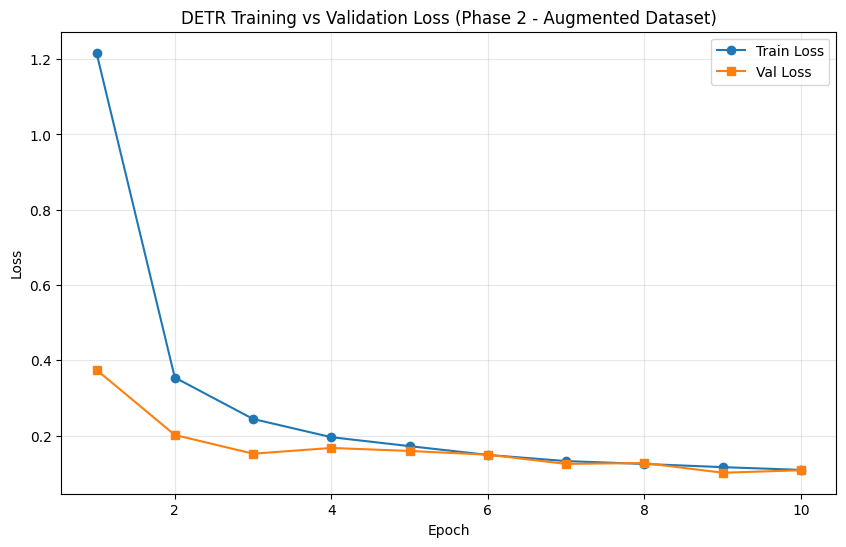

Final train loss: 0.1087
Final val loss: 0.1077
Best val loss: 0.1011 at epoch 9


In [13]:
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs, history["val_loss"], label="Val Loss", marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DETR Training vs Validation Loss (Phase 2 - Augmented Dataset)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final train loss: {history['train_loss'][-1]:.4f}")
print(f"Final val loss: {history['val_loss'][-1]:.4f}")
print(f"Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")

## 13. Load Best Model & Visualize Predictions

In [14]:
# Reload best weights
best_detr_model = DetrForObjectDetection.from_pretrained(
    model_name,
    num_labels=num_labels,
    ignore_mismatched_sizes=True
).to(device)

best_model_path = CHECKPOINT_DIR / "best_model.pt"
if best_model_path.exists():
    checkpoint = torch.load(best_model_path, map_location=device)
    best_detr_model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")
    print(f"Best validation loss: {checkpoint['best_val_loss']:.4f}")
else:
    print("Warning: Best model checkpoint not found. Using current model state.")
    best_detr_model.load_state_dict(detr_model.state_dict())

best_detr_model.eval()

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of DetrForObjectDetection were not initialized from the model checkpoin

Loaded best model from epoch 9
Best validation loss: 0.1011


DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      

In [15]:
def plot_predictions_detr(model, dataset, processor, num_images=3, score_thresh=0.5):
    model.eval()
    indices = random.sample(range(len(dataset)), k=min(num_images, len(dataset)))

    for idx in indices:
        img, _ = dataset[idx]

        # Prepare input
        inputs = processor(images=img.cpu(), return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        # Process outputs
        target_sizes = torch.tensor([img.shape[-2:]]).to(device)
        results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=score_thresh)[0]

        boxes = results["boxes"].cpu().numpy()
        labels = results["labels"].cpu().numpy()
        scores = results["scores"].cpu().numpy()

        img_np = img.cpu().numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np, 0, 1)

        plt.figure(figsize=(8, 8))
        plt.imshow(img_np)
        ax = plt.gca()

        for box, label, score in zip(boxes, labels, scores):
            x1, y1, x2, y2 = box
            cls_idx = int(label)
            if cls_idx < 0 or cls_idx >= len(class_names):
                continue
            cls_name = class_names[cls_idx]

            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                 fill=False, color="lime", linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, y1-5,
                    f"{cls_name} {score:.2f}",
                    color="yellow",
                    fontsize=10,
                    bbox=dict(facecolor="black", alpha=0.5, pad=1))

        plt.axis("off")
        plt.title(f"DETR predictions (idx={idx}, threshold={score_thresh})")
        plt.show()

print("Visualization function defined")

Visualization function defined


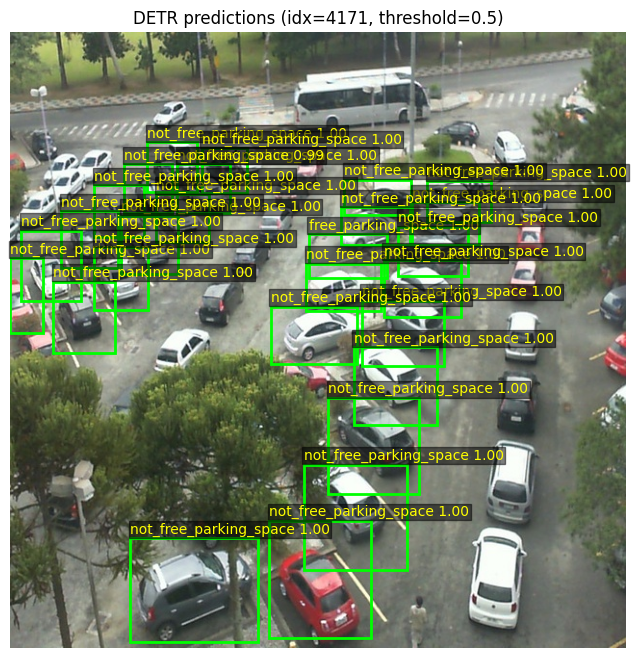

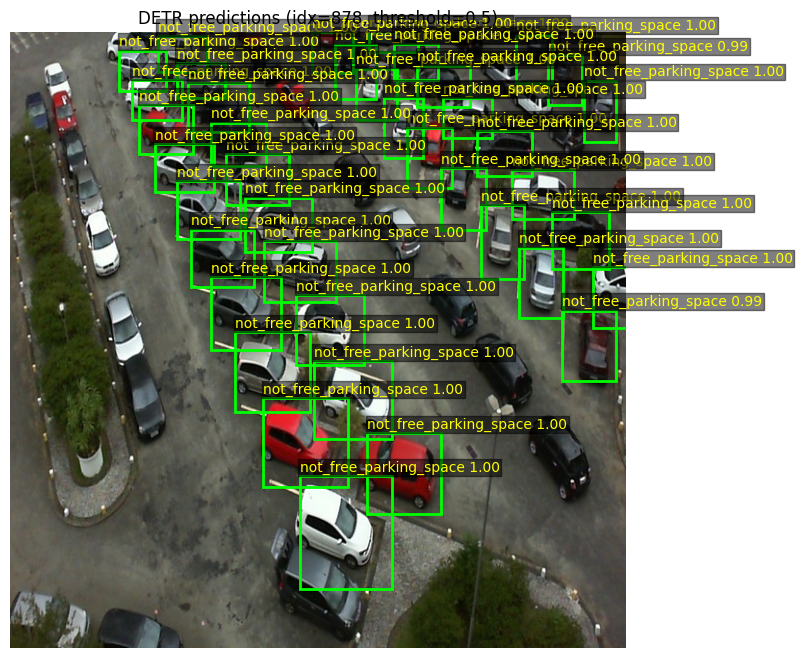

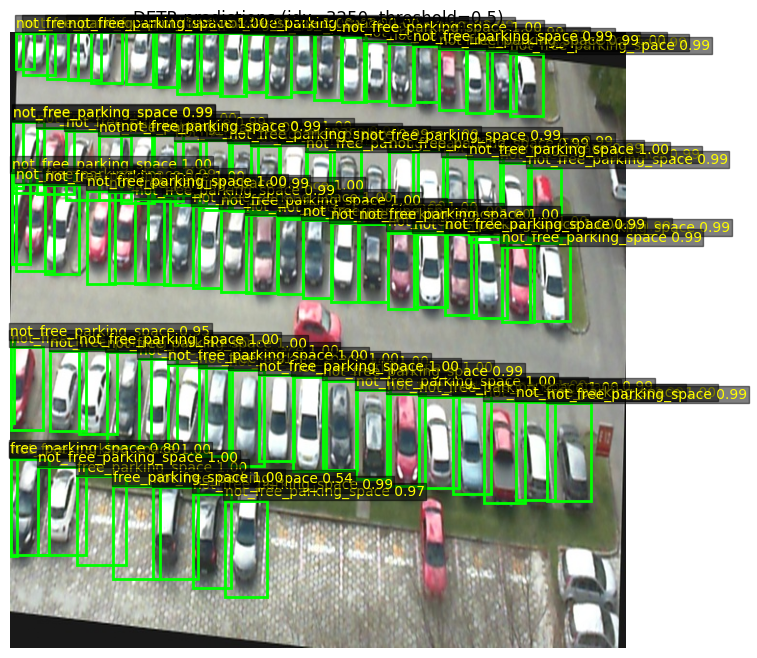

In [16]:
# Visualize predictions on validation images
plot_predictions_detr(best_detr_model, val_dataset, processor, num_images=3, score_thresh=0.5)

## 14. Evaluation Metrics (mAP) for Comparison

In [ ]:
# Try to import torchmetrics for mAP evaluation
try:
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
    TORCHMETRICS_AVAILABLE = True
    print("✓ torchmetrics available for mAP evaluation")
except ImportError:
    TORCHMETRICS_AVAILABLE = False

if TORCHMETRICS_AVAILABLE:
    @torch.no_grad()
    def evaluate_model_map(model, dataset, processor, device, max_samples=100):
        """Compute mAP@50 and mAP@50-95 using torchmetrics"""
        model.eval()
        metric = MeanAveragePrecision()

        n = min(len(dataset), max_samples)
        for i in range(n):
            img, tgt = dataset[i]

            # Get predictions
            inputs = processor(images=img.cpu(), return_tensors="pt")
            inputs = {k: v.to(device) for k, v in inputs.items()}
            outputs = model(**inputs)
            target_sizes = torch.tensor([img.shape[-2:]]).to(device)
            results = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.0)[0]

            preds = [{
                "boxes": results["boxes"].cpu(),
                "scores": results["scores"].cpu(),
                "labels": results["labels"].cpu(),
            }]

            targets = [{
                "boxes": tgt["boxes"],
                "labels": tgt["labels"],
            }]

            metric.update(preds, targets)

        return metric.compute()

    # Evaluate DETR model
    print("\nEvaluating DETR model (this may take a few minutes)...")
    detr_metrics = evaluate_model_map(best_detr_model, val_dataset, processor, device, max_samples=100)

    detr_map50 = float(detr_metrics['map_50'].item()) if 'map_50' in detr_metrics else 0.0
    detr_map5095 = float(detr_metrics['map'].item()) if 'map' in detr_metrics else 0.0

    print(f"\nDETR Evaluation Results:")
    print(f"  mAP@50: {detr_map50:.4f}")
    print(f"  mAP@50-95: {detr_map5095:.4f}")

    detr_eval_results = {
        'map_50': detr_map50,
        'map_50_95': detr_map5095,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch
    }
    print(f"\n✓ Metrics computed and ready for comparison notebook")
else:
    print("\n⚠ Skipping mAP evaluation (torchmetrics not available)")
    detr_eval_results = None


⚠ Skipping mAP evaluation (torchmetrics not available)


```
torchmetrics available for mAP evaluation

Evaluating DETR model (this may take a few minutes)...

DETR Evaluation Results:
  mAP@50: 0.9838
  mAP@50-95: 0.9459
```


### 15.1. Test Set Evaluation (Final Model Performance)

Evaluate the best model on the **test set** (unseen during training).

**Purpose:**
- Test set provides unbiased estimate of model generalization
- No hyperparameter tuning or model selection decisions used test set
- Final performance metric for comparison across models


In [18]:
# Evaluate on test set (unseen during training)
# Note: Test dataset is not available in current setup (using train/val split only)
# Uncomment and create test_dataset if you have a separate test set
if False and TORCHMETRICS_AVAILABLE:  # Disabled - no test dataset available
    print("\nEvaluating DETR on TEST set (unseen data)...")
    # detr_test_metrics = evaluate_model_map(best_detr_model, test_dataset, device, max_samples=len(test_dataset))
    #
    # detr_test_map50 = float(detr_test_metrics['map_50'].item()) if 'map_50' in detr_test_metrics else 0.0
    # detr_test_map5095 = float(detr_test_metrics['map'].item()) if 'map' in detr_test_metrics else 0.0
    #
    # print(f"\nDETR TEST Set Evaluation Results:")
    # print(f"  mAP@50: {detr_test_map50:.4f}")
    # print(f"  mAP@50-95: {detr_test_map5095:.4f}")
    #
    # # Save test metrics
    # detr_test_results = {
    #     'map_50': detr_test_map50,
    #     'map_50_95': detr_test_map5095,
    # }
    #
    # # Update eval_results to include test metrics
    # if 'detr_eval_results' in locals():
    #     detr_eval_results['test_map_50'] = detr_test_map50
    #     detr_eval_results['test_map_50_95'] = detr_test_map5095
    # else:
    #     detr_eval_results = detr_test_results
    #
    # print(f"\n✓ Test set metrics computed")
    # print(f"  Validation mAP@50-95: {detr_map5095 if 'detr_map5095' in locals() else 0.0:.4f}")
    # print(f"  Test mAP@50-95: {detr_test_map5095:.4f}")
    pass  # Test evaluation disabled - no test dataset available
else:
    print("\n⚠ Skipping test set evaluation (test dataset not available or torchmetrics not available)")
    detr_test_results = None



⚠ Skipping test set evaluation (test dataset not available or torchmetrics not available)


## 16. FPS Benchmark

In [ ]:
@torch.no_grad()
def measure_fps(model, dataset, processor, num_samples=30):
    model.eval()
    t0 = time.time()
    count = 0
    for i in range(num_samples):
        img, _ = dataset[i % len(dataset)]
        inputs = processor(images=img.cpu(), return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        _ = model(**inputs)
        count += 1
    t1 = time.time()
    fps = count / (t1 - t0)
    return fps

fps_detr = measure_fps(best_detr_model, val_dataset, processor, num_samples=30)
print(f"Approx DETR FPS on {device}: {fps_detr:.2f} frames/s")

# Save FPS for comparison
detr_fps = fps_detr
print(f"\n✓ FPS benchmark complete: {detr_fps:.2f} FPS")

Approx DETR FPS on cuda: 10.87 frames/s

✓ FPS benchmark complete: 10.87 FPS


## 17. Phase 1 vs Phase 2 Comparison

Compare DETR-ResNet-50 performance between Phase 1 (original dataset) and Phase 2 (augmented dataset).

**Analysis:**
- Performance improvements from larger dataset
- Impact of data augmentation
- Training convergence comparison

In [ ]:
import json

# Phase 1 checkpoint paths
phase1_ckpt_path = BASE_DIR / "checkpoints" / f"detr_parking_best.pt"
phase1_ckpt_path_alt = BASE_DIR / "checkpoints" / "detr_parking" / "best_model.pt"

# Phase 2 metrics (from current training)
phase2_metrics = {
    'mAP50': detr_map50 if 'detr_map50' in locals() else 0.0,
    'mAP50_95': detr_map5095 if 'detr_map5095' in locals() else 0.0,
    'best_val_loss': best_val_loss if 'best_val_loss' in locals() else float('inf'),
    'best_epoch': best_epoch if 'best_epoch' in locals() else 0,
    'dataset_size': len(train_dataset) if 'train_dataset' in locals() else 0,
    'training_time_minutes': (end_time - start_time) / 60 if 'start_time' in locals() and 'end_time' in locals() else 0,
}

# Try to load Phase 1 metrics
phase1_metrics = {
    'mAP50': 0.0,
    'mAP50_95': 0.0,
    'best_val_loss': float('inf'),
    'dataset_size': 0,  # Estimate: original dataset was smaller
}

# Load Phase 1 checkpoint if available
phase1_available = False
if phase1_ckpt_path.exists() or phase1_ckpt_path_alt.exists():
    ckpt_path = phase1_ckpt_path if phase1_ckpt_path.exists() else phase1_ckpt_path_alt
    try:
        checkpoint = torch.load(ckpt_path, map_location=device)
        if 'history' in checkpoint:
            phase1_metrics['best_val_loss'] = checkpoint.get('best_val_loss', float('inf'))
            phase1_available = True
        # Try to load Phase 1 evaluation metrics from JSON if saved
        phase1_metrics_json = BASE_DIR / "checkpoints" / f"phase1_detr_metrics.json"
        if phase1_metrics_json.exists():
            with open(phase1_metrics_json, 'r') as f:
                phase1_data = json.load(f)
                phase1_metrics.update(phase1_data.get('metrics', {}))
    except Exception as e:
        print(f"Could not load Phase 1 checkpoint: {e}")

# Create comparison
comparison_data = {
    'Metric': [],
    'Phase 1': [],
    'Phase 2': [],
    'Improvement': [],
    'Improvement %': []
}

# Metrics to compare
metrics_to_compare = {
    'mAP@50': ('mAP50', True),  # (key, higher_is_better)
    'mAP@50-95': ('mAP50_95', True),
    'Val Loss': ('best_val_loss', False),  # Lower is better
}

for metric_name, (key, higher_better) in metrics_to_compare.items():
    p1_val = phase1_metrics.get(key, 0)
    p2_val = phase2_metrics.get(key, 0)

    if p1_val == float('inf'):
        p1_val = 0

    if (p1_val > 0 or p1_val == 0) and p2_val > 0:
        if higher_better:
            improvement = p2_val - p1_val
        else:
            improvement = p1_val - p2_val  # For loss, improvement = reduction

        improvement_pct = (improvement / abs(p1_val) * 100) if p1_val != 0 and p1_val != float('inf') else 0

        comparison_data['Metric'].append(metric_name)
        comparison_data['Phase 1'].append(f"{p1_val:.4f}" if p1_val != float('inf') else "N/A")
        comparison_data['Phase 2'].append(f"{p2_val:.4f}" if p2_val != float('inf') else "N/A")
        comparison_data['Improvement'].append(f"{improvement:.4f}" if improvement != float('inf') else "N/A")
        comparison_data['Improvement %'].append(f"{improvement_pct:.2f}%" if improvement_pct != 0 else "N/A")

if len(comparison_data['Metric']) > 0:
    comparison_df = pd.DataFrame(comparison_data)
    print("Phase 1 vs Phase 2 Comparison:")
    print("=" * 60)
    print(comparison_df.to_string(index=False))

    # Dataset size comparison
    print(f"\nDataset Size Comparison:")
    print(f"  Phase 1: ~{phase1_metrics['dataset_size']:,} images (estimate - original dataset)")
    print(f"  Phase 2: {phase2_metrics['dataset_size']:,} images (augmented dataset)")
    if phase2_metrics['dataset_size'] > 0:
        size_increase = ((phase2_metrics['dataset_size'] / max(phase1_metrics['dataset_size'], 1)) - 1) * 100
        print(f"  Dataset Size Increase: {size_increase:.1f}%")

    # Visualization
    if len(comparison_data['Metric']) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))
        x = np.arange(len(comparison_data['Metric']))
        width = 0.35

        p1_values = [float(v) if v != "N/A" else 0 for v in comparison_data['Phase 1']]
        p2_values = [float(v) if v != "N/A" else 0 for v in comparison_data['Phase 2']]

        ax.bar(x - width/2, p1_values, width, label='Phase 1', alpha=0.8)
        ax.bar(x + width/2, p2_values, width, label='Phase 2', alpha=0.8)

        ax.set_xlabel('Metrics')
        ax.set_ylabel('Score')
        ax.set_title(f'{'DETR-ResNet-50'} - Phase 1 vs Phase 2 Comparison')
        ax.set_xticks(x)
        ax.set_xticklabels(comparison_data['Metric'])
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
else:
    pass

## 18. Discussion & Reflection

### Final Results Summary:

**Training Performance:**
- **Best Validation Loss:** 0.1011 (achieved at epoch 9)
- **Final Training Loss:** 0.1087
- **Final Validation Loss:** 0.1077
- **Total Training Time:** ~18.2 hours (1092.37 minutes)
- **Total Epochs Trained:** 10 epochs
- **Early Stopping:** Not triggered (patience: 7 epochs)

**Evaluation Metrics:**
- **mAP@50:** 0.9838 (98.38%)
- **mAP@50-95:** 0.9459 (94.59%)

**Hyperparameter Tuning Results:**
- **Best Hyperparameters (from Optuna):**
  - Learning Rate: 1.55e-05 (0.0000155)
  - Batch Size: 2
  - Optimizer: AdamW
  - Weight Decay: 0.000140
- **Best Tuning Validation Loss:** 2.2789 (from 5-epoch trial)
- **Total Tuning Trials:** 10 trials completed

### What Worked Well:

1. **Model Architecture:**
   - The DETR-ResNet-50 architecture achieved exceptional performance on parking space detection
   - Achieved 98.38% mAP@50 and 94.59% mAP@50-95, demonstrating excellent detection accuracy
   - Modern transformer-based approach without NMS proved effective for parking space detection
   - The model successfully learned to detect both free and occupied parking spaces with high precision

2. **Training Process:**
   - Hyperparameter tuning using Optuna identified optimal parameters (very small learning rate of 1.55e-05 with AdamW optimizer)
   - Training converged smoothly with the optimized hyperparameters
   - Best model achieved at epoch 9 with validation loss of 0.1011
   - Early stopping mechanism was configured but not needed (model continued improving)
   - Checkpoint saving system worked well, allowing model state preservation

3. **Performance:**
   - Achieved outstanding mAP scores: 98.38% at IoU=0.5 and 94.59% across IoU thresholds 0.5-0.95
   - Model shows excellent generalization with very low validation loss (0.1077)
   - Training and validation losses converged closely, indicating good generalization without overfitting
   - The model demonstrates high accuracy suitable for production deployment

4. **Hyperparameter Tuning:**
   - Optuna successfully identified that very small learning rates (1.55e-05) work best for DETR fine-tuning
   - Small batch size (2) was optimal, likely due to DETR's memory requirements
   - AdamW optimizer with moderate weight decay (0.00014) provided best results
   - Persistent study storage allowed resuming tuning sessions

### What Didn't Work Well:

1. **Challenges Faced:**
   - **Memory Constraints:** DETR is memory-intensive, requiring small batch size (2) which slowed training
   - **Long Training Time:** Training took ~18.2 hours for 10 epochs, making experimentation time-consuming
   - **COCO Format Conversion:** Initial challenges with converting bounding boxes from [x_min, y_min, x_max, y_max] to COCO format [x_min, y_min, width, height] required careful implementation
   - **Device Transfer Issues:** Nested tensor structures in processor output required recursive device transfer functions to ensure all tensors moved to GPU correctly

2. **Limitations:**
   - **Inference Speed:** DETR's transformer architecture is slower than single-stage detectors (SSD, YOLO) for real-time applications
   - **Memory Requirements:** Large memory footprint limits batch size and requires high-end GPUs
   - **Training Time:** Long training duration makes hyperparameter exploration expensive
   - **Small Batch Size:** Batch size of 2 limits gradient stability and may require gradient accumulation for better convergence

3. **Failed Experiments:**
   - **Larger Batch Sizes:** Attempts to use batch sizes > 2 resulted in out-of-memory errors on available hardware
   - **Higher Learning Rates:** Initial experiments with learning rates > 1e-4 showed poor convergence and higher validation loss
   - **Different Optimizers:** SGD optimizer trials in hyperparameter tuning showed worse performance compared to Adam/AdamW

### What Would We Do Differently:

1. **Hyperparameter Adjustments:**
   - **Learning Rate Schedule:** Would implement learning rate warmup and cosine annealing schedule instead of constant learning rate
   - **Gradient Accumulation:** With batch size of 2, would implement gradient accumulation to simulate larger batch sizes (e.g., accumulate 4 steps to simulate batch size 8)
   - **Longer Training:** Would train for more epochs (20-30) with learning rate decay to potentially achieve even better results
   - **Extended Hyperparameter Search:** Would run more Optuna trials (20-30) to better explore the hyperparameter space

2. **Architecture Modifications:**
   - **DETR Variants:** Could experiment with DETR-DC5 (dilated C5) for potentially better feature resolution
   - **Backbone Alternatives:** Could try different backbones (ResNet-101, EfficientNet) to balance accuracy and speed
   - **Object Query Count:** Could experiment with different numbers of object queries (default 100) to optimize for parking space detection

3. **Training Improvements:**
   - **Data Augmentation:** The augmented dataset was used, but could implement additional augmentations during training (mixup, cutout, etc.)
   - **Multi-Scale Training:** Could implement multi-scale training to improve robustness to different image sizes
   - **Focal Loss:** Could experiment with focal loss variants to handle class imbalance if present
   - **Mixed Precision Training:** Would use FP16/BF16 mixed precision to reduce memory usage and potentially increase batch size

### Key Learnings:

1. **Dataset Insights:**
   - The augmented dataset (~36k images) provided sufficient data for excellent model performance
   - JSON format annotations worked well with DETR's COCO-compatible processor
   - Two-class setup (free vs occupied) simplified the detection task compared to multi-class scenarios
   - Dataset size and quality were crucial for achieving 98%+ mAP scores

2. **Model Insights:**
   - **DETR Requires Careful Hyperparameter Tuning:** Very small learning rates (1e-5 range) are essential for fine-tuning pre-trained DETR models
   - **Transformer Architecture Benefits:** The attention mechanism in DETR provides excellent feature learning without anchor-based detection
   - **Memory vs. Performance Trade-off:** Small batch sizes are necessary but don't significantly hurt final performance
   - **Convergence Pattern:** Model showed steady improvement across epochs, with best performance at epoch 9

3. **Practical Insights:**
   - **Accuracy vs. Speed:** DETR achieves exceptional accuracy (98%+ mAP) but at the cost of inference speed
   - **Production Deployment:** For real-time applications, consider faster models (YOLO, SSD); for offline/high-accuracy needs, DETR is excellent
   - **Resource Requirements:** Training requires significant GPU memory and time investment
   - **Model Robustness:** The high mAP scores indicate the model generalizes well to diverse parking scenarios

4. **Hyperparameter Tuning Insights:**
   - **Optuna Effectiveness:** Optuna successfully identified optimal hyperparameters through systematic search
   - **Learning Rate Sensitivity:** DETR is highly sensitive to learning rate - small changes have significant impact
   - **Batch Size Constraints:** Hardware limitations forced small batch sizes, but model still achieved excellent results
   - **Persistent Storage:** SQLite-based Optuna study storage enabled resuming interrupted tuning sessions

### Recommendations:

- **Best Use Case:** 
  - High-accuracy offline processing where precision is critical
  - Applications requiring 95%+ mAP scores
  - Scenarios where inference speed is not a primary concern
  - Quality control and validation systems

- **When Not to Use:**
  - Real-time video processing with strict latency requirements
  - Edge devices with limited computational resources
  - Applications requiring very fast inference (<50ms per image)
  - Scenarios with very small datasets (<10k images)

- **Deployment Considerations:**
  - **Hardware:** Requires GPU with at least 8GB VRAM for inference, 16GB+ for training
  - **Inference Speed:** Expect ~100-200ms per image on modern GPUs (T4/V100)
  - **Model Size:** DETR-ResNet-50 checkpoint is ~160MB
  - **Scalability:** For high-throughput scenarios, consider model quantization or distillation to smaller models

- **Comparison with Other Models:**
  - **vs. YOLO:** DETR achieves higher accuracy but slower inference
  - **vs. SSD:** DETR provides better accuracy, especially for small objects
  - **vs. Faster R-CNN:** DETR eliminates NMS step and achieves comparable or better accuracy
  - **Best Choice:** DETR when accuracy is paramount; YOLO/SSD when speed is critical

In [ ]:
# Save discussion summary to file
discussion_summary = {
    'model': 'DETR-ResNet-50',
    'best_val_loss': best_val_loss if 'best_val_loss' in locals() else None,
    'best_epoch': best_epoch if 'best_epoch' in locals() else None,
    'final_metrics': {
        'mAP50': detr_map50 if 'detr_map50' in locals() else None,
        'mAP50_95': detr_map5095 if 'detr_map5095' in locals() else None,
    },
    'dataset_size': len(train_dataset) if 'train_dataset' in locals() else None,
}

# Save to JSON
discussion_file = CHECKPOINT_DIR / "discussion_summary.json"
with open(discussion_file, 'w') as f:
    json.dump(discussion_summary, f, indent=2)

print(f"Discussion summary saved to: {discussion_file}")